# Sanity check — Inspection des .npz preprocessed

Vérifie la qualité des signaux preprocessed avant de lancer la détection sable.

**Ce qu'on vérifie** :
1. Shape cohérente (signal_final = sacrum_xyz_raw // DECIMATE_FACTOR)
2. Oscillations propres dans la bande [0.5–2.5 Hz] (= sélection IMF a marché)
3. Pas de saut/discontinuité brutale (= preprocess + crop OK)
4. Spectrogramme : fréquence dominante centrée sur cadence de marche

In [1]:
from resilience import paths, participants, config
from resilience.io import writer
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
%matplotlib inline

## 1. Vue d'ensemble — signal_final empilé pour les 41 essais

Total essais à inspecter : 38


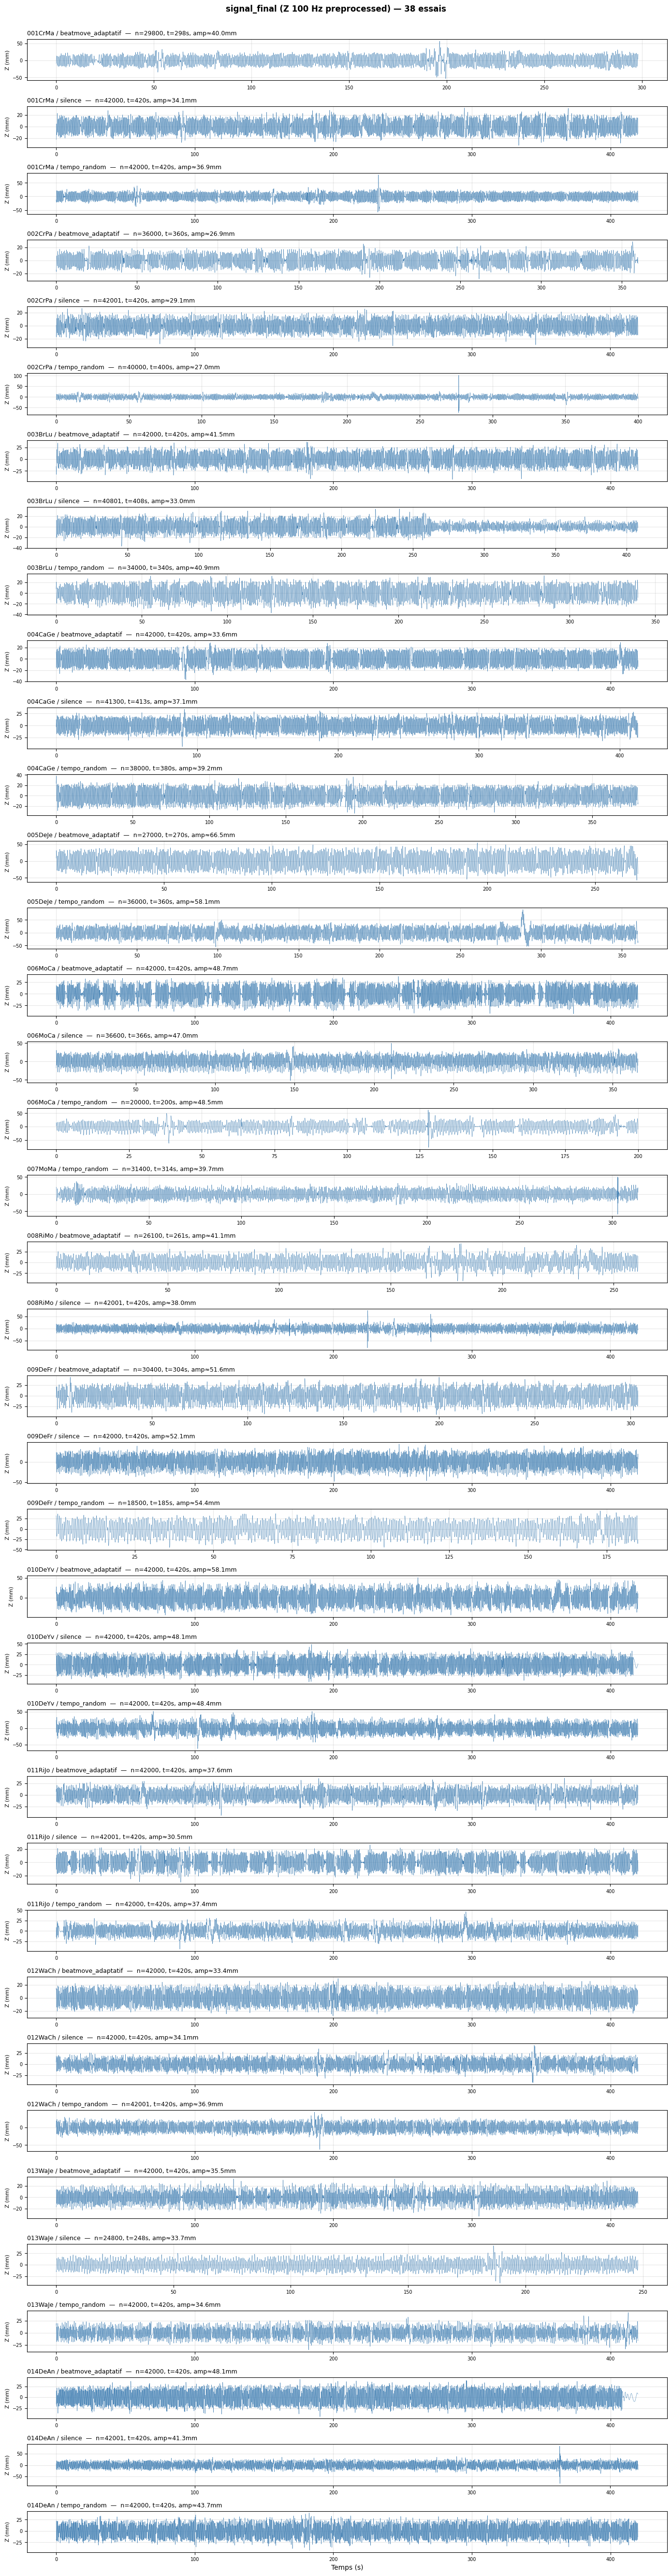

In [2]:
TRIALS = participants.list_trials_to_process()
print(f"Total essais à inspecter : {len(TRIALS)}")

n_plots = len(TRIALS)
fig, axes = plt.subplots(n_plots, 1, figsize=(14, 1.4 * n_plots), sharex=False)

for ax, (p, c) in zip(axes, TRIALS):
    try:
        payload = writer.load_processed(p, c)
        sig = payload['signal_final']
        t = payload['time_final']
        ax.plot(t, sig, color='steelblue', linewidth=0.4)
        
        # Stats
        amp = float(np.percentile(sig, 95) - np.percentile(sig, 5))
        ax.set_title(f"{p} / {c}  —  n={len(sig)}, t={t[-1]:.0f}s, amp≈{amp:.1f}mm",
                     fontsize=9, loc='left')
        ax.set_ylabel('Z (mm)', fontsize=8)
        ax.grid(alpha=0.3)
        ax.tick_params(labelsize=7)
    except Exception as e:
        ax.text(0.5, 0.5, f'❌ {type(e).__name__}: {e}',
                ha='center', va='center', transform=ax.transAxes,
                color='red', fontsize=8)
        ax.set_title(f"{p} / {c}", fontsize=9, loc='left')

axes[-1].set_xlabel('Temps (s)')
plt.suptitle(f'signal_final (Z 100 Hz preprocessed) — {len(TRIALS)} essais',
             fontsize=12, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('sanity_check_signals.png', dpi=80, bbox_inches='tight')
plt.show()

## 2. Spectres de puissance — vérifier que la cadence est bien dans la bande

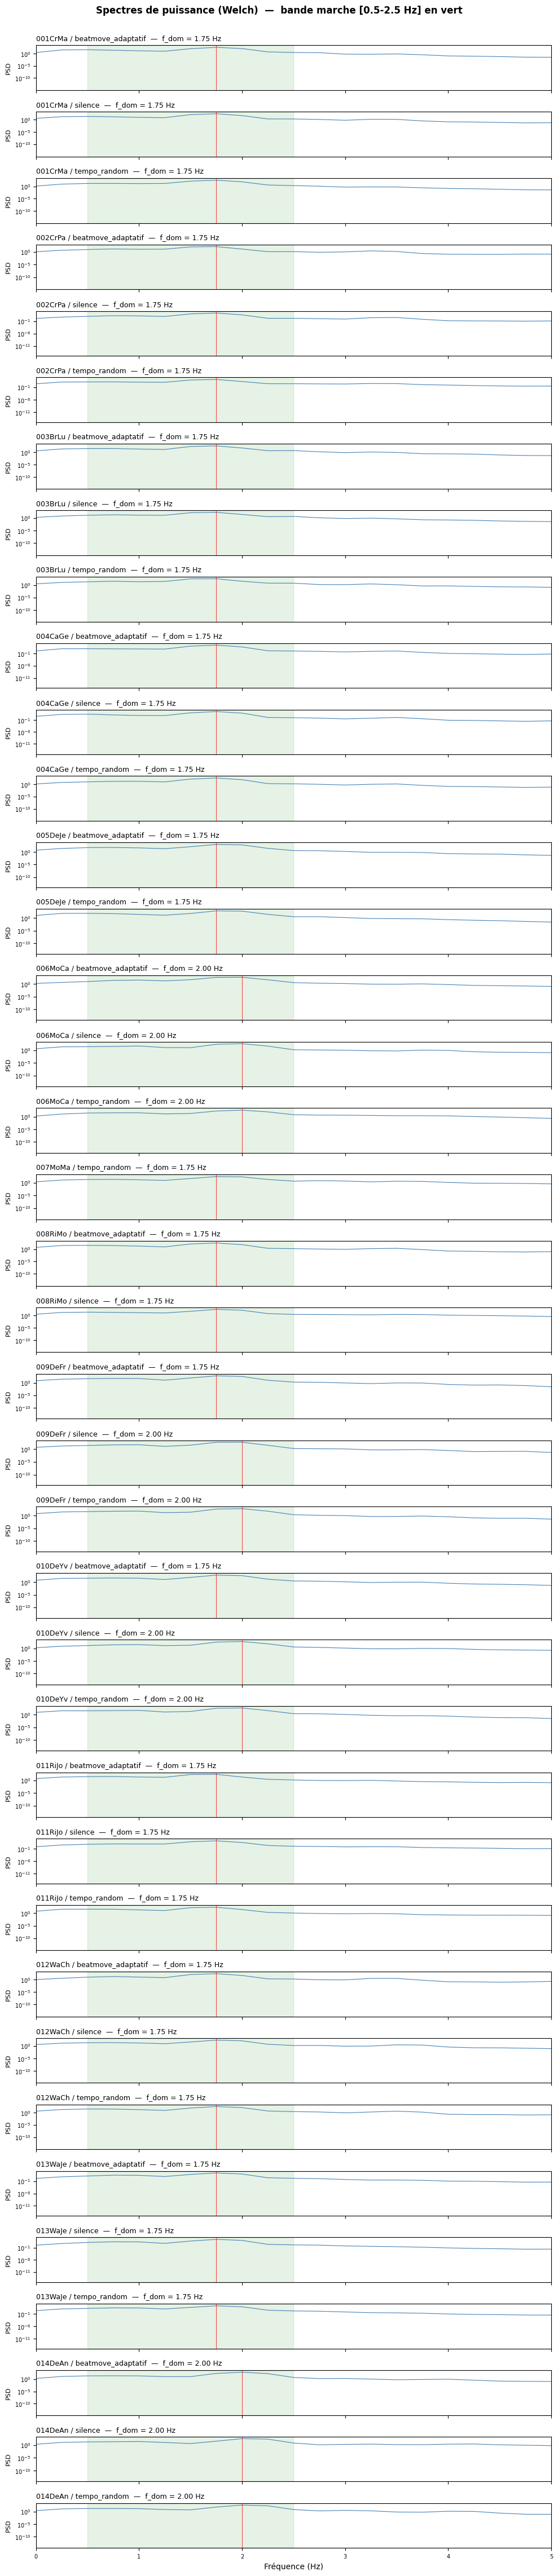

In [3]:
fs = config.FS_CLEAN
band_low, band_high = config.WALKING_BAND_HZ

fig, axes = plt.subplots(n_plots, 1, figsize=(10, 1.2 * n_plots), sharex=True)

for ax, (p, c) in zip(axes, TRIALS):
    try:
        payload = writer.load_processed(p, c)
        sig = payload['signal_final']
        f, pxx = welch(sig, fs=fs, nperseg=min(len(sig), 4*fs))
        ax.semilogy(f, pxx, color='steelblue', linewidth=0.8)
        
        # Bande de marche en vert clair
        ax.axvspan(band_low, band_high, color='green', alpha=0.1)
        
        # Pic dominant
        mask = (f >= band_low) & (f <= band_high)
        if mask.any():
            f_dom = f[mask][np.argmax(pxx[mask])]
            ax.axvline(f_dom, color='red', linewidth=0.8, alpha=0.7)
            ax.set_title(f"{p} / {c}  —  f_dom = {f_dom:.2f} Hz", fontsize=9, loc='left')
        else:
            ax.set_title(f"{p} / {c}", fontsize=9, loc='left')
        
        ax.set_ylabel('PSD', fontsize=8)
        ax.set_xlim(0, 5)
        ax.tick_params(labelsize=7)
    except Exception as e:
        ax.set_title(f"{p} / {c} — erreur", fontsize=9, loc='left')

axes[-1].set_xlabel('Fréquence (Hz)')
plt.suptitle(f'Spectres de puissance (Welch)  —  bande marche [{band_low}-{band_high} Hz] en vert',
             fontsize=12, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('sanity_check_spectra.png', dpi=80, bbox_inches='tight')
plt.show()

## 3. Tableau récapitulatif — toutes les fréquences dominantes

In [4]:
import pandas as pd

rows = []
for p, c in TRIALS:
    try:
        payload = writer.load_processed(p, c)
        sig = payload['signal_final']
        t = payload['time_final']
        f, pxx = welch(sig, fs=config.FS_CLEAN, nperseg=min(len(sig), 4*config.FS_CLEAN))
        mask = (f >= config.WALKING_BAND_HZ[0]) & (f <= config.WALKING_BAND_HZ[1])
        f_dom = float(f[mask][np.argmax(pxx[mask])]) if mask.any() else np.nan
        amp = float(np.percentile(sig, 95) - np.percentile(sig, 5))
        
        rows.append({
            'participant': p,
            'condition':   c,
            'n_samples':   len(sig),
            'duration_s':  round(float(t[-1]), 1),
            'f_dom_Hz':    round(f_dom, 2),
            'cadence_spm': round(f_dom * 60, 0),   # steps per minute
            'amplitude_mm': round(amp, 1),
        })
    except Exception as e:
        rows.append({'participant': p, 'condition': c, 'erreur': str(e)})

df = pd.DataFrame(rows)
df

,participant,condition,n_samples,duration_s,f_dom_Hz,cadence_spm,amplitude_mm
0,001CrMa,beatmove_adaptatif,29800,298.0,1.75,105.0,40.0
1,001CrMa,silence,42000,420.0,1.75,105.0,34.1
2,001CrMa,tempo_random,42000,420.0,1.75,105.0,36.9
3,002CrPa,beatmove_adaptatif,36000,360.0,1.75,105.0,26.9
4,002CrPa,silence,42001,420.0,1.75,105.0,29.1
5,002CrPa,tempo_random,40000,400.0,1.75,105.0,27.0
6,003BrLu,beatmove_adaptatif,42000,420.0,1.75,105.0,41.5
7,003BrLu,silence,40801,408.0,1.75,105.0,33.0
8,003BrLu,tempo_random,34000,340.0,1.75,105.0,40.9
9,004CaGe,beatmove_adaptatif,42000,420.0,1.75,105.0,33.6


## 4. Distribution des fréquences et amplitudes — sanity stat

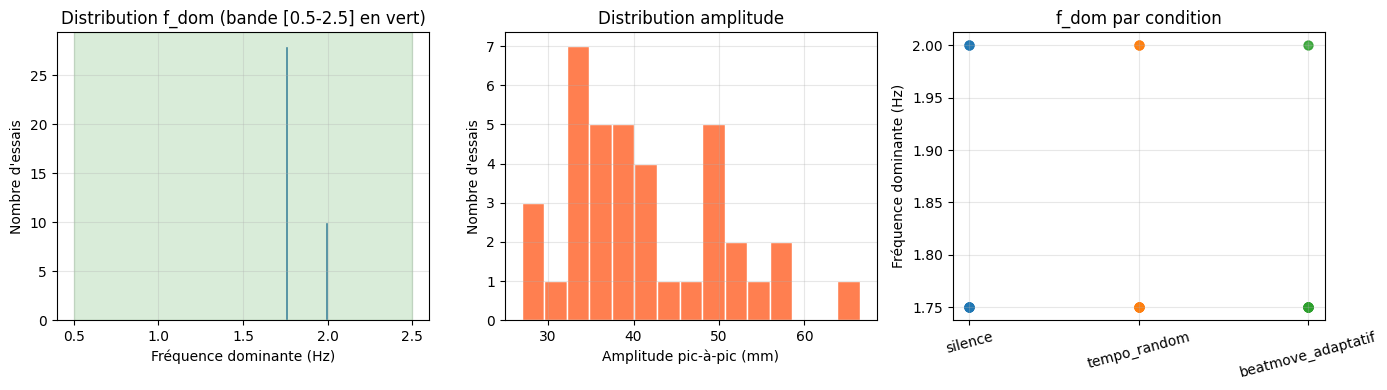


Fréquence dominante  : 1.82 ± 0.11 Hz
Cadence              : 109 ± 7 pas/min
Amplitude pic-à-pic  : 41.2 ± 9.1 mm

Valeurs attendues 65+ :
  Cadence  : 85-130 pas/min  → 109 ✅
  Amplitude: 30-60 mm        → 41.2 ✅


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Distribution f_dom
axes[0].hist(df['f_dom_Hz'].dropna(), bins=15, color='steelblue', edgecolor='white')
axes[0].axvspan(config.WALKING_BAND_HZ[0], config.WALKING_BAND_HZ[1],
                color='green', alpha=0.15)
axes[0].set_xlabel('Fréquence dominante (Hz)')
axes[0].set_ylabel('Nombre d\'essais')
axes[0].set_title('Distribution f_dom (bande [0.5-2.5] en vert)')
axes[0].grid(alpha=0.3)

# 2. Distribution amplitude
axes[1].hist(df['amplitude_mm'].dropna(), bins=15, color='coral', edgecolor='white')
axes[1].set_xlabel('Amplitude pic-à-pic (mm)')
axes[1].set_ylabel('Nombre d\'essais')
axes[1].set_title('Distribution amplitude')
axes[1].grid(alpha=0.3)

# 3. f_dom par condition
for i, cond in enumerate(['silence', 'tempo_random', 'beatmove_adaptatif']):
    sub = df[df['condition'] == cond]['f_dom_Hz'].dropna()
    axes[2].scatter([i]*len(sub), sub, alpha=0.6, s=40)
axes[2].set_xticks([0, 1, 2])
axes[2].set_xticklabels(['silence', 'tempo_random', 'beatmove_adaptatif'], rotation=15)
axes[2].set_ylabel('Fréquence dominante (Hz)')
axes[2].set_title('f_dom par condition')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Stats résumé
print(f"\nFréquence dominante  : {df['f_dom_Hz'].mean():.2f} ± {df['f_dom_Hz'].std():.2f} Hz")
print(f"Cadence              : {df['cadence_spm'].mean():.0f} ± {df['cadence_spm'].std():.0f} pas/min")
print(f"Amplitude pic-à-pic  : {df['amplitude_mm'].mean():.1f} ± {df['amplitude_mm'].std():.1f} mm")
print(f"\nValeurs attendues 65+ :")
print(f"  Cadence  : 85-130 pas/min  → {df['cadence_spm'].mean():.0f} {'✅' if 85 <= df['cadence_spm'].mean() <= 130 else '⚠️'}")
print(f"  Amplitude: 30-60 mm        → {df['amplitude_mm'].mean():.1f} {'✅' if 20 <= df['amplitude_mm'].mean() <= 80 else '⚠️'}")

## 5. Zoom sur 1 essai — détail du signal preprocessing

Vérifier que le signal a bien la tête attendue (oscillations propres, pas de saut).

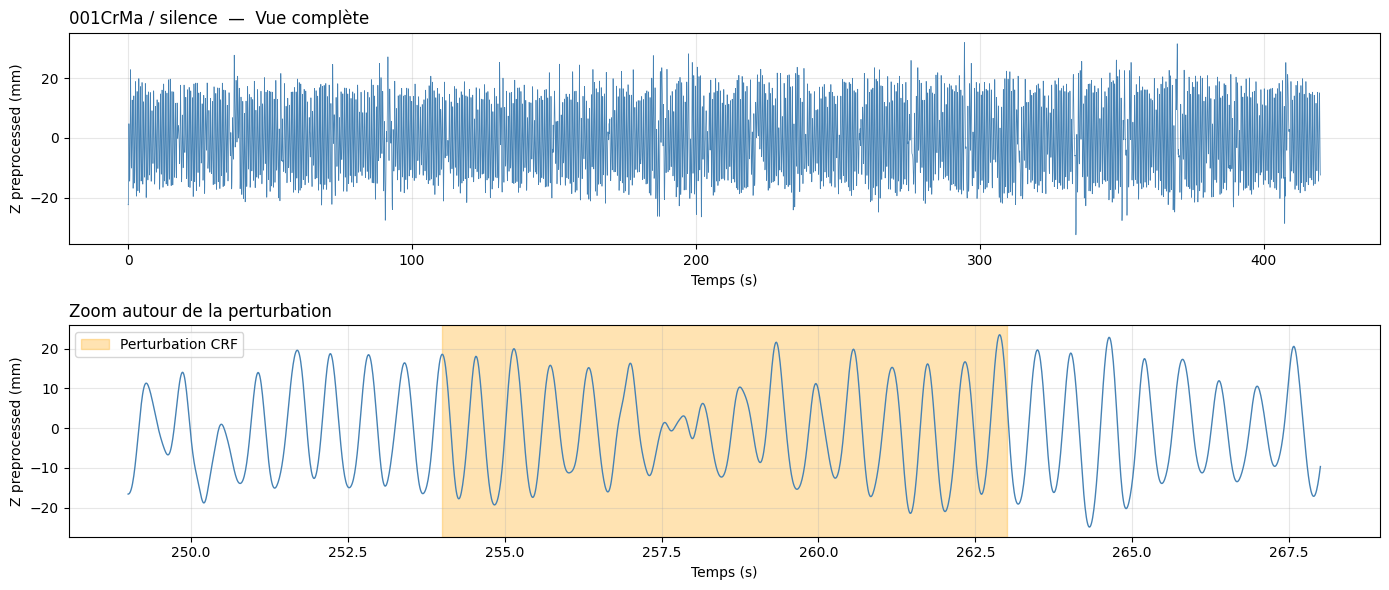

In [6]:
ZOOM_P = '001CrMa'
ZOOM_C = 'silence'

payload = writer.load_processed(ZOOM_P, ZOOM_C)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

# Vue complète
axes[0].plot(payload['time_final'], payload['signal_final'],
             color='steelblue', linewidth=0.5)
axes[0].set_title(f"{ZOOM_P} / {ZOOM_C}  —  Vue complète", loc='left')
axes[0].set_xlabel('Temps (s)')
axes[0].set_ylabel('Z preprocessed (mm)')
axes[0].grid(alpha=0.3)

# Zoom 10s autour de la perturbation
trial = participants.get_trial(ZOOM_P, ZOOM_C)
if trial.crf_entry_s is not None:
    t0 = trial.crf_entry_s - 5
    t1 = trial.crf_exit_s + 5
    mask = (payload['time_final'] >= t0) & (payload['time_final'] <= t1)
    axes[1].plot(payload['time_final'][mask], payload['signal_final'][mask],
                 color='steelblue', linewidth=1)
    axes[1].axvspan(trial.crf_entry_s, trial.crf_exit_s, color='orange', alpha=0.3,
                    label='Perturbation CRF')
    axes[1].set_title(f"Zoom autour de la perturbation", loc='left')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Pas de CRF disponible pour cet essai',
                 ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('Temps (s)')
axes[1].set_ylabel('Z preprocessed (mm)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()